# Feature Validation Plots (Interactive)

This notebook validates extracted features against raw IMU signals for one chosen folder.

You can:
- choose a directory using **tkinter**, or
- use `DATA_ROOT / PATIENT_ID / DATE`.

It supports layouts where activity CSVs are direct or nested. If multiple files match,
it prefers filenames containing `synchronized`.

## Imports

In [1]:
from pathlib import Path
import re
import warnings
import tkinter as tk
from tkinter import filedialog
import ipywidgets as widgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.signal.windows import tukey
from ssqueezepy import ssq_cwt

from imu_features.config import PipelineConfig
from imu_features.utils import (
    preprocess_activity_dataframe,
    standardize_sensor_columns,
    timestamp_to_seconds,
    detect_peaks,
    dominant_frequency,
    safe_gradient,
    count_pauses,
    estimate_sampling_interval_s,
    select_motion_acc_signal,
    select_turn_angular_signal,
    adaptive_amplitude_threshold,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configuration

In [2]:
DATA_ROOT = Path("Data")
PATIENT_ID = "patient_103"
DATE = "2026-03-08"             # e.g. "2026-03-08" or "D1_2025-03-23"; None => latest
ACTIVITY_FILTER = None         # e.g. ["walk", "left_turn"]
USE_TKINTER_CHOOSER = True     # set True to open folder chooser UI

PLOT_PARAMS = {
    "step_min_distance_alpha": 0.5,
    "pause_min_duration_beta": 0.6,
    "plot_walk_histogram": True,
    "walk_variance_window_sec": 0.50,
    "walk_compare_fs_hz": 10,
    "walk_compare_min_amp": 0.30,
    "walk_compare_min_t_sec": 3,
    "walk_compare_step_freq_hz": (0.8, 2.3),
    "adaptive_thresholds": {
        "quiet_window_sec": 1.0,
        "min_window_samples": 10,
        "step_threshold_k": 4.0,
        "turn_threshold_k": 3.0,
        "pause_threshold_k": 1.5,
        "transition_threshold_k": 2.0,
        "step_threshold_min": 0.05,
        "turn_threshold_min": 0.05,
        "pause_threshold_min": 0.02,
        "transition_threshold_min": 0.03,
    },
}

COLUMN_MAPPING_OVERRIDE = {
    "timestamp": ["Timestamp", "timestamp", "time", "Time"],
    "accel_x": ["Accel_X", "accel_x", "acc_x"],
    "accel_y": ["Accel_Y", "accel_y", "acc_y"],
    "accel_z": ["Accel_Z", "accel_z", "acc_z"],
    "useracc_x": ["UserAccel_X", "useracc_x", "linacc_x", "linearacc_x"],
    "useracc_y": ["UserAccel_Y", "useracc_y", "linacc_y", "linearacc_y"],
    "useracc_z": ["UserAccel_Z", "useracc_z", "linacc_z", "linearacc_z"],
    "gyro_x": ["Gyro_X", "gyro_x", "gyr_x"],
    "gyro_y": ["Gyro_Y", "gyro_y", "gyr_y"],
    "gyro_z": ["Gyro_Z", "gyro_z", "gyr_z"],
}

PIPELINE_CONFIG = PipelineConfig()
PIPELINE_CONFIG.column_candidates = COLUMN_MAPPING_OVERRIDE
print("Config ready")

Config ready


## Choose Folder With Tkinter (Optional)

In [3]:
CHOSEN_DIR = None


def choose_directory_tkinter(initial_dir=None):
    if tk is None or filedialog is None:
        print("tkinter not available; using DATA_ROOT from config.")
        return None

    try:
        import subprocess
        import sys

        # On macOS, activate Finder first so chooser is front/visible.
        if sys.platform == "darwin":
            default_dir = str((initial_dir or DATA_ROOT).resolve())
            escaped_dir = default_dir.replace('"', '\"')
            script = (
                'tell application "Finder" to activate\n'
                'set chosenFolder to choose folder with prompt "Choose activity date folder" '
                f'default location POSIX file "{escaped_dir}"\n'
                'POSIX path of chosenFolder'
            )
            proc = subprocess.run(
                ["osascript", "-e", script],
                capture_output=True,
                text=True,
                check=False,
            )
            if proc.returncode == 0:
                selected = proc.stdout.strip()
                return Path(selected) if selected else None
            err = (proc.stderr or "").strip()
            if err:
                print(f"macOS chooser error: {err}")
            return None

        # Fallback for non-macOS.
        root = tk.Tk()
        root.withdraw()
        root.update_idletasks()

        selected = filedialog.askdirectory(
            initialdir=str(initial_dir or DATA_ROOT),
            title="Choose activity date folder",
            mustexist=True,
        )

        root.destroy()
        return Path(selected) if selected else None
    except Exception as exc:
        print(f"tkinter chooser unavailable ({exc}); using configured path.")
        return None


CHOSEN_DIR = choose_directory_tkinter(initial_dir=DATA_ROOT) if USE_TKINTER_CHOOSER else None
print("Chosen directory:", CHOSEN_DIR)


Chosen directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23


## Activity Dropdown

In [4]:
SELECTED_ACTIVITIES = ACTIVITY_FILTER

try:
    import ipywidgets as widgets
    from IPython.display import display

    activity_ms = widgets.SelectMultiple(
        options=["walk", "left_turn", "right_turn", "sit_to_stand", "stand_to_sit"],
        description="Activity",
    )

    def apply_activities(_):
        global SELECTED_ACTIVITIES
        SELECTED_ACTIVITIES = list(activity_ms.value) if len(activity_ms.value) else None
        print("Applied SELECTED_ACTIVITIES:", SELECTED_ACTIVITIES)

    btn = widgets.Button(description="Apply Activities")
    btn.on_click(apply_activities)
    display(activity_ms, btn)
except Exception as e:
    print("ipywidgets unavailable; using ACTIVITY_FILTER from config")
    print(e)

SelectMultiple(description='Activity', options=('walk', 'left_turn', 'right_turn', 'sit_to_stand', 'stand_to_s…

Button(description='Apply Activities', style=ButtonStyle())

## Helpers

In [5]:
ACTIVITY_ALIASES = {
    "walk": ["walk", "10_mw", "10mw", "1m", "1 meter"],
    "left_turn": ["left_turn", "left turn", "l_360", "360 left", "left"],
    "right_turn": ["right_turn", "right turn", "r_360", "360 right", "right"],
    "sit_to_stand": ["sit_to_stand", "sit to stand", "sit_stand", "sitstand"],
    "stand_to_sit": ["stand_to_sit", "stand to sit", "stand_sit", "standsit"],
}


def _norm_text(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()


def resolve_date_dir(data_root, patient_id, date):
    patient_dir = Path(data_root) / patient_id
    if not patient_dir.exists():
        raise FileNotFoundError(f"Patient folder not found: {patient_dir}")

    if date is None:
        date_dirs = sorted([d for d in patient_dir.iterdir() if d.is_dir()])
        if not date_dirs:
            raise FileNotFoundError(f"No date folders under: {patient_dir}")
        return date_dirs[-1]

    direct = patient_dir / str(date)
    if direct.exists():
        return direct

    candidates = [d for d in patient_dir.rglob("*") if d.is_dir() and d.name == str(date)]
    if candidates:
        return sorted(candidates, key=lambda p: len(p.parts))[0]

    raise FileNotFoundError(f"Date folder not found: {date}")


def discover_activity_files(base_dir, activity_filter=None):
    # Recursive discovery with synchronized-file preference
    base_dir = Path(base_dir)
    if not base_dir.exists():
        return {}

    csv_paths = sorted([p for p in base_dir.rglob("*.csv") if p.is_file()])
    discovered = {}

    for activity, aliases in ACTIVITY_ALIASES.items():
        if activity_filter and activity not in set(activity_filter):
            continue

        candidates = []
        for p in csv_paths:
            probe = _norm_text(p.stem + " " + p.parent.name + " " + str(p))
            alias_rank = None
            for rank, alias in enumerate(aliases):
                if _norm_text(alias) in probe:
                    alias_rank = rank
                    break
            if alias_rank is None:
                continue

            sync_rank = 0 if "synchronized" in p.name.lower() else 1
            score = (alias_rank, sync_rank, len(p.parts), len(p.name), p.name.lower())
            candidates.append((score, p))

        if candidates:
            discovered[activity] = sorted(candidates, key=lambda x: x[0])[0][1]

    return discovered


def load_activity_file(path):
    raw = pd.read_csv(path)
    return preprocess_activity_dataframe(raw, PIPELINE_CONFIG)


def standardize_columns(df):
    return standardize_sensor_columns(df, PIPELINE_CONFIG.column_candidates)


def compute_time_seconds(df):
    ts = pd.Series(timestamp_to_seconds(df["timestamp"]), dtype=float)
    return ts - ts.dropna().iloc[0] if ts.notna().any() else ts


def compute_acc_magnitude(df):
    if "useracc_mag" in df and np.isfinite(df["useracc_mag"]).any():
        return df["useracc_mag"].to_numpy(dtype=float), "useracc_mag"
    if all(c in df for c in ["accel_x", "accel_y", "accel_z"]):
        m = np.sqrt(df["accel_x"]**2 + df["accel_y"]**2 + df["accel_z"]**2)
        return m.to_numpy(dtype=float), "acc_mag"
    return np.full(len(df), np.nan), "acc_mag"


def compute_gyro_magnitude(df):
    if "gyro_mag" in df:
        return df["gyro_mag"].to_numpy(dtype=float)
    if all(c in df for c in ["gyro_x", "gyro_y", "gyro_z"]):
        m = np.sqrt(df["gyro_x"]**2 + df["gyro_y"]**2 + df["gyro_z"]**2)
        return m.to_numpy(dtype=float)
    return np.full(len(df), np.nan)


def _acf_norm(sig):
    x = np.asarray(sig, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.array([])
    x = x - np.mean(x)
    if np.allclose(x, 0):
        return np.array([])
    acf = np.correlate(x, x, mode="full")
    acf = acf[len(x)-1:]
    return acf / acf[0] if acf[0] != 0 else np.array([])

## Plot Functions

In [6]:
def _window_signal(time_s, signal, start_t, end_t):
    time_s = np.asarray(time_s, dtype=float)
    signal = np.asarray(signal, dtype=float)
    if len(time_s) != len(signal) or len(time_s) < 3:
        return np.array([]), np.array([])
    if not np.isfinite(start_t) or not np.isfinite(end_t) or end_t <= start_t:
        return np.array([]), np.array([])

    mask = (time_s >= start_t) & (time_s <= end_t) & np.isfinite(signal) & np.isfinite(time_s)
    if mask.sum() < 3:
        return np.array([]), np.array([])
    return time_s[mask], signal[mask]


def _window_peak_to_peak_from_signal(t, signal, window_sec=1.0):
    t = np.asarray(t, dtype=float)
    signal = np.asarray(signal, dtype=float)
    if len(t) == 0 or len(signal) == 0 or len(t) != len(signal):
        return np.array([], dtype=float), np.array([], dtype=float)
    if not np.isfinite(window_sec) or window_sec <= 0:
        window_sec = 1.0
    t0 = float(t[0])
    t1 = float(t[-1])
    if not np.isfinite(t0) or not np.isfinite(t1) or t1 < t0:
        return np.array([], dtype=float), np.array([], dtype=float)
    n_windows = int(np.floor((t1 - t0) / window_sec)) + 1
    if n_windows <= 0:
        return np.array([], dtype=float), np.array([], dtype=float)
    starts = []
    pp = []
    for i in range(n_windows):
        start = t0 + i * window_sec
        end = start + window_sec
        if i == n_windows - 1:
            mask = (t >= start) & (t <= end)
        else:
            mask = (t >= start) & (t < end)
        window = signal[mask]
        window = window[np.isfinite(window)]
        starts.append(start)
        if len(window) == 0:
            pp.append(np.nan)
        else:
            pp.append(float(np.nanmax(window) - np.nanmin(window)))
    return np.asarray(starts, dtype=float), np.asarray(pp, dtype=float)


def _window_signal_envelope(t, signal, window_sec=1.0):
    t = np.asarray(t, dtype=float)
    signal = np.asarray(signal, dtype=float)
    if len(t) == 0 or len(signal) == 0 or len(t) != len(signal):
        return np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)
    if not np.isfinite(window_sec) or window_sec <= 0:
        window_sec = 1.0
    t0 = float(t[0])
    t1 = float(t[-1])
    if not np.isfinite(t0) or not np.isfinite(t1) or t1 < t0:
        return np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)
    n_windows = int(np.floor((t1 - t0) / window_sec)) + 1
    if n_windows <= 0:
        return np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)
    starts = []
    mins = []
    maxs = []
    mids = []
    for i in range(n_windows):
        start = t0 + i * window_sec
        end = start + window_sec
        if i == n_windows - 1:
            mask = (t >= start) & (t <= end)
        else:
            mask = (t >= start) & (t < end)
        window = signal[mask]
        window = window[np.isfinite(window)]
        starts.append(start)
        if len(window) == 0:
            mins.append(np.nan)
            maxs.append(np.nan)
            mids.append(np.nan)
        else:
            wmin = float(np.nanmin(window))
            wmax = float(np.nanmax(window))
            mins.append(wmin)
            maxs.append(wmax)
            mids.append(0.5 * (wmin + wmax))
    return np.asarray(starts, dtype=float), np.asarray(mins, dtype=float), np.asarray(maxs, dtype=float), np.asarray(mids, dtype=float)


def _resample_signal_to_n(time_s, signal, n_points=100):
    time_s = np.asarray(time_s, dtype=float)
    signal = np.asarray(signal, dtype=float)
    if len(time_s) < 3 or len(signal) < 3 or n_points < 3:
        return np.array([]), np.array([])

    order = np.argsort(time_s)
    time_s = time_s[order]
    signal = signal[order]
    keep = np.isfinite(time_s) & np.isfinite(signal)
    time_s = time_s[keep]
    signal = signal[keep]
    if len(time_s) < 3:
        return np.array([]), np.array([])

    unique_t, unique_idx = np.unique(time_s, return_index=True)
    signal = signal[unique_idx]
    time_s = unique_t
    if len(time_s) < 3 or time_s[-1] <= time_s[0]:
        return np.array([]), np.array([])

    resampled_t = np.linspace(time_s[0], time_s[-1], n_points)
    resampled_x = np.interp(resampled_t, time_s, signal)
    return resampled_t, resampled_x


def _normalize_signal(signal):
    signal = np.asarray(signal, dtype=float)
    if len(signal) < 3:
        return np.array([])
    signal = signal[np.isfinite(signal)]
    if len(signal) < 3:
        return np.array([])
    signal = signal - np.mean(signal)
    std = np.std(signal)
    if not np.isfinite(std) or std == 0:
        return np.array([])
    return signal / std


def _windowed_resampled_pair(data_a, data_b, n_points=100):
    ta, xa = _window_signal(
        data_a['time'], data_a['signal'],
        data_a['summary']['start_time_s'], data_a['summary']['end_time_s']
    )
    tb, xb = _window_signal(
        data_b['time'], data_b['signal'],
        data_b['summary']['start_time_s'], data_b['summary']['end_time_s']
    )
    if len(ta) < 3 or len(tb) < 3:
        return np.array([]), np.array([]), np.nan

    ta_r, xa_r = _resample_signal_to_n(ta, xa, n_points=n_points)
    tb_r, xb_r = _resample_signal_to_n(tb, xb, n_points=n_points)
    xa_n = _normalize_signal(xa_r)
    xb_n = _normalize_signal(xb_r)
    if len(xa_n) < 3 or len(xb_n) < 3:
        return np.array([]), np.array([]), np.nan

    duration_a = float(data_a['summary']['end_time_s'] - data_a['summary']['start_time_s'])
    duration_b = float(data_b['summary']['end_time_s'] - data_b['summary']['start_time_s'])
    mean_duration = np.nanmean([duration_a, duration_b])
    lag_step_s = (mean_duration / (n_points - 1)) if np.isfinite(mean_duration) and mean_duration > 0 else np.nan
    return xa_n, xb_n, lag_step_s


def _normalized_xcorr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or len(y) < 3 or len(x) != len(y):
        return np.array([]), np.array([])

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3 or len(x) != len(y):
        return np.array([]), np.array([])

    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom == 0:
        return np.array([]), np.array([])

    corr = np.correlate(x, y, mode='full') / denom
    lags = np.arange(-len(x) + 1, len(x))
    return lags, corr


def _best_xcorr_summary(data_a, data_b, n_points=100):
    x, y, lag_step_s = _windowed_resampled_pair(data_a, data_b, n_points=n_points)
    lags, corr = _normalized_xcorr(x, y)
    if len(corr) == 0:
        return lags, corr, np.nan, np.nan, lag_step_s

    i = int(np.argmax(np.abs(corr)))
    peak = float(corr[i])
    lag_s = float(lags[i] * lag_step_s) if np.isfinite(lag_step_s) else np.nan
    return lags, corr, peak, lag_s, lag_step_s


def _mask_close_gaps(mask, max_gap_samples):
    if max_gap_samples <= 0 or len(mask) == 0:
        return mask

    out = mask.copy()
    i = 0
    n = len(out)
    while i < n:
        if out[i]:
            i += 1
            continue
        j = i
        while j < n and not out[j]:
            j += 1
        gap_len = j - i
        left_on = i > 0 and out[i - 1]
        right_on = j < n and out[j]
        if left_on and right_on and gap_len <= max_gap_samples:
            out[i:j] = True
        i = j
    return out


def _largest_segment(mask):
    best = None
    i = 0
    n = len(mask)
    while i < n:
        if not mask[i]:
            i += 1
            continue
        j = i
        while j < n and mask[j]:
            j += 1
        if best is None or (j - i) > (best[1] - best[0]):
            best = (i, j - 1)
        i = j
    return best


def _detect_active_window(signal, t, min_duration_s=0.8, threshold=None):
    signal = np.asarray(signal, dtype=float)
    t = np.asarray(t, dtype=float)

    if len(signal) == 0 or len(t) == 0:
        return np.nan, np.nan, np.nan, np.zeros(0, dtype=bool), np.nan

    fs_hz = 1.0 / estimate_sampling_interval_s(t) if len(t) > 2 else np.nan

    baseline = np.nanmedian(signal)
    motion = np.abs(signal - baseline)

    if threshold is None:
        q70 = np.nanpercentile(motion, 70) if np.isfinite(motion).any() else np.nan
        q90 = np.nanpercentile(motion, 90) if np.isfinite(motion).any() else np.nan
        if np.isfinite(q70) and np.isfinite(q90):
            threshold = q70 + 0.15 * (q90 - q70)
        else:
            threshold = np.nan

    if not np.isfinite(threshold):
        return np.nan, np.nan, np.nan, np.zeros(len(t), dtype=bool), np.nan

    active = np.isfinite(motion) & (motion >= threshold)

    if np.isfinite(fs_hz) and fs_hz > 0:
        active = _mask_close_gaps(active, max_gap_samples=max(1, int(0.25 * fs_hz)))

    seg = _largest_segment(active)
    if seg is None:
        return np.nan, np.nan, np.nan, np.zeros(len(t), dtype=bool), threshold

    i0, i1 = seg
    start_t = float(t[i0])
    end_t = float(t[i1])
    duration = float(end_t - start_t)

    if duration < min_duration_s:
        return np.nan, np.nan, np.nan, np.zeros(len(t), dtype=bool), threshold

    mask = np.zeros(len(t), dtype=bool)
    mask[i0:i1 + 1] = True
    return start_t, end_t, duration, mask, threshold




def _apply_notebook_adaptive_settings():
    adaptive_cfg = PIPELINE_CONFIG.adaptive_thresholds
    settings = PLOT_PARAMS.get('adaptive_thresholds', {})
    for key, value in settings.items():
        if hasattr(adaptive_cfg, key):
            setattr(adaptive_cfg, key, value)
    return adaptive_cfg


def _adaptive_step_min_distance(t, candidate_peaks):
    t = np.asarray(t, dtype=float)
    candidate_peaks = np.asarray(candidate_peaks, dtype=int)
    if len(candidate_peaks) < 2:
        return np.nan

    dt = np.diff(t[candidate_peaks])
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        return np.nan

    return float(PLOT_PARAMS.get('step_min_distance_alpha', 0.5) * np.nanmedian(dt))


def _pause_segment_durations(values, t, threshold):
    values = np.asarray(values, dtype=float)
    t = np.asarray(t, dtype=float)
    if len(values) != len(t) or len(values) < 2:
        return np.array([], dtype=float)

    pause_mask = np.isfinite(values) & (np.abs(values) < threshold)
    if not np.any(pause_mask):
        return np.array([], dtype=float)

    starts = np.where(~pause_mask[:-1] & pause_mask[1:])[0] + 1
    ends = np.where(pause_mask[:-1] & ~pause_mask[1:])[0] + 1
    if pause_mask[0]:
        starts = np.insert(starts, 0, 0)
    if pause_mask[-1]:
        ends = np.append(ends, len(pause_mask))

    durations = []
    for start, end in zip(starts, ends):
        if end - start < 2:
            continue
        duration = float(t[end - 1] - t[start])
        if np.isfinite(duration) and duration > 0:
            durations.append(duration)
    return np.asarray(durations, dtype=float)


def _adaptive_pause_min_duration(values, t, threshold):
    durations = _pause_segment_durations(values, t, threshold)
    if len(durations) == 0:
        return 0.0
    return float(PLOT_PARAMS.get('pause_min_duration_beta', 0.5) * np.nanmedian(durations))


def _sliding_mean_mad_threshold(signal, fs_hz, window_sec, k):
    signal = np.asarray(signal, dtype=float)
    if len(signal) == 0:
        return np.array([])

    if np.isfinite(fs_hz) and fs_hz > 0 and np.isfinite(window_sec) and window_sec > 0:
        window_n = int(round(window_sec * fs_hz))
    else:
        window_n = 5
    window_n = max(3, window_n)

    out = np.full(len(signal), np.nan, dtype=float)
    half = window_n // 2
    for i in range(len(signal)):
        i0 = max(0, i - half)
        i1 = min(len(signal), i + half + 1)
        window = signal[i0:i1]
        window = window[np.isfinite(window)]
        if len(window) < 3:
            continue
        baseline_mean = float(np.nanmean(window))
        baseline_median = float(np.nanmedian(window))
        spread_mad = float(np.nanmedian(np.abs(window - baseline_median)))
        thr = baseline_mean + k * spread_mad
        out[i] = thr

    valid = np.isfinite(out)
    if valid.any() and (~valid).any():
        idx = np.arange(len(out), dtype=float)
        out[~valid] = np.interp(idx[~valid], idx[valid], out[valid])
    return out






def _compare_adjust_bout(inarray, fs=10):
    inarray = np.asarray(inarray, dtype=float)
    if len(inarray) == 0:
        return np.array([])
    rem = len(inarray) % fs
    if rem >= int(np.ceil(0.7 * fs)):
        pad_n = fs - rem
        if pad_n < fs:
            inarray = np.append(inarray, np.repeat(inarray[-1], pad_n))
    elif rem != 0:
        inarray = inarray[: (len(inarray) // fs) * fs]
    return inarray


def _compare_preprocess_bout(t_bout, vm_bout, fs=10):
    t_bout = np.asarray(t_bout, dtype=float)
    vm_bout = np.asarray(vm_bout, dtype=float)
    keep = np.isfinite(t_bout) & np.isfinite(vm_bout)
    t_bout = t_bout[keep]
    vm_bout = vm_bout[keep]
    if len(t_bout) < 2 or len(vm_bout) < 2 or not np.isfinite(fs) or fs <= 0:
        return np.array([]), np.array([])
    t_rel = t_bout - t_bout[0]
    t_interp = np.arange(t_rel[0], t_rel[-1], 1.0 / fs)
    if len(t_interp) < 2:
        return np.array([]), np.array([])
    t_interp = t_interp + t_bout[0]
    f = interpolate.interp1d(t_bout, vm_bout, bounds_error=False, fill_value='extrapolate')
    vm_interp = f(t_interp)
    vm_interp = _compare_adjust_bout(vm_interp, fs)
    t_interp = t_interp[:len(vm_interp)]
    if len(vm_interp) < fs:
        return np.array([]), np.array([])
    return t_interp, vm_interp


def _compare_get_pp(vm_bout, fs=10):
    vm_bout = np.asarray(vm_bout, dtype=float)
    if len(vm_bout) < fs:
        return np.array([])
    vm_res_sec = vm_bout.reshape((fs, -1), order='F')
    return np.ptp(vm_res_sec, axis=0)


def _compare_compute_interpolate_cwt(tapered_bout, fs=10):
    tapered_bout = np.asarray(tapered_bout, dtype=float)
    if len(tapered_bout) < fs:
        return np.array([]), np.array([[]])
    window = tukey(len(tapered_bout), alpha=0.02, sym=True)
    padded = np.concatenate((np.zeros(5 * fs), tapered_bout * window, np.zeros(5 * fs)))
    Tx, Wx, ssq_freqs, scales, *_ = ssq_cwt(padded[:-1], wavelet=('gmw', {'beta': 90, 'gamma': 3}), fs=fs)
    coefs = np.abs(Wx.astype('complex128') ** 2)
    coefs = np.append(coefs, coefs[:, -1:], axis=1)
    freqs_interp = np.arange(0.5, 4.5, 0.05)
    # scipy interp2d is gone in recent versions; use row-wise np.interp
    time_idx = np.arange(coefs.shape[1], dtype=float)
    coefs_interp = np.vstack([
        np.interp(freqs_interp, ssq_freqs[::-1], coefs[:, j][::-1])
        for j in range(coefs.shape[1])
    ]).T
    coefs_interp = coefs_interp[:, 5 * fs : -5 * fs]
    return freqs_interp, coefs_interp


def _compare_identify_peaks_in_cwt(freqs_interp, coefs_interp, fs=10, step_freq=(1.4, 2.3), alpha=0.6, beta=2.5):
    if coefs_interp.size == 0:
        return np.array([[]])
    num_rows, num_cols = coefs_interp.shape
    num_cols2 = int(num_cols / fs)
    dp = np.zeros((num_rows, num_cols2))
    loc_min = np.argmin(np.abs(freqs_interp - step_freq[0]))
    loc_max = np.argmin(np.abs(freqs_interp - step_freq[1]))
    for i in range(num_cols2):
        x_start = i * fs
        x_end = (i + 1) * fs
        window = np.sum(coefs_interp[:, np.arange(x_start, x_end)], axis=1)
        locs = detect_peaks(window, fs_hz=np.nan, min_distance_s=np.nan, height=None)
        locs = np.asarray(locs, dtype=int)
        if len(locs) == 0:
            continue
        pks = window[locs]
        ind = np.argsort(-pks)
        locs = locs[ind]
        pks = pks[ind]
        index_in_range = None
        for j, locs_j in enumerate(locs):
            if loc_min <= locs_j <= loc_max:
                index_in_range = j
                break
        peak_vec = np.zeros(num_rows)
        if index_in_range is not None:
            if locs[0] > loc_max:
                if pks[0] / pks[index_in_range] < beta:
                    peak_vec[locs[index_in_range]] = 1
            elif locs[0] < loc_min:
                if pks[0] / pks[index_in_range] < alpha:
                    peak_vec[locs[index_in_range]] = 1
            else:
                peak_vec[locs[index_in_range]] = 1
        dp[:, i] = peak_vec
    return dp


def _compare_find_continuous_dominant_peaks(valid_peaks, min_t=3, delta=20):
    valid_peaks = np.asarray(valid_peaks, dtype=float)
    if valid_peaks.size == 0:
        return valid_peaks
    num_rows, num_cols = valid_peaks.shape
    extended_peaks = np.zeros((num_rows, num_cols + 1), dtype=valid_peaks.dtype)
    extended_peaks[:, :num_cols] = valid_peaks
    cont_peaks = np.zeros_like(extended_peaks)
    for slice_ind in range(num_cols + 1 - min_t):
        slice_mat = extended_peaks[:, slice_ind:slice_ind + min_t].copy()
        windows = list(range(min_t)) + list(range(min_t - 2, -1, -1))
        stop = True
        for win_ind in windows:
            pr = np.where(slice_mat[:, win_ind] != 0)[0]
            stop = True
            for p in pr:
                index = np.arange(max(0, p - delta), min(p + delta + 1, num_rows))
                peaks1 = slice_mat[p, win_ind]
                peaks2 = peaks1
                if win_ind == 0:
                    peaks1 += slice_mat[index, win_ind + 1]
                elif win_ind == min_t - 1:
                    peaks1 += slice_mat[index, win_ind - 1]
                else:
                    peaks1 += slice_mat[index, win_ind - 1]
                    peaks2 += slice_mat[index, win_ind + 1]
                if win_ind == 0 or win_ind == min_t - 1:
                    if np.any(peaks1 > 1):
                        stop = False
                    else:
                        slice_mat[p, win_ind] = 0
                else:
                    if np.any(peaks1 > 1) and np.any(peaks2 > 1):
                        stop = False
                    else:
                        slice_mat[p, win_ind] = 0
            if stop:
                break
        if not stop:
            cont_peaks[:, slice_ind:slice_ind + min_t] += slice_mat
    cont_peaks = np.where(cont_peaks > 0, 1, 0)
    return cont_peaks[:, :num_cols]


def exact_compare_walk_summary(t, acc, fs_hz):
    compare_fs = int(PLOT_PARAMS.get('walk_compare_fs_hz', 10))
    min_amp = float(PLOT_PARAMS.get('walk_compare_min_amp', 0.30))
    min_t = int(PLOT_PARAMS.get('walk_compare_min_t_sec', 3))
    step_freq = PLOT_PARAMS.get('walk_compare_step_freq_hz', (0.8, 2.3))
    alpha = 0.6
    beta = 2.5
    delta = 20

    t_res, vm_bout = _compare_preprocess_bout(t, acc, fs=compare_fs)
    if len(vm_bout) < compare_fs:
        return {'t_res': np.array([]), 'vm_bout': np.array([]), 'cad': np.array([]), 'dominant_freq_hz': np.array([]), 'pp': np.array([]), 'min_amp': min_amp, 'walk_mask': np.array([], dtype=bool), 'start_time_s': np.nan, 'end_time_s': np.nan, 'duration_s': np.nan, 'step_count': np.nan, 'cadence': np.nan}

    pp = _compare_get_pp(vm_bout, compare_fs)
    valid = np.ones(len(pp), dtype=bool)
    valid[pp < min_amp] = False
    cad = np.zeros(len(pp), dtype=float)
    dominant_freq_hz = np.full(len(pp), np.nan, dtype=float)
    if np.sum(valid) >= min_t:
        tapered_bout = vm_bout[np.repeat(valid, compare_fs)]
        freqs_interp, coefs_interp = _compare_compute_interpolate_cwt(tapered_bout, fs=compare_fs)
        if coefs_interp.size:
            dp = _compare_identify_peaks_in_cwt(freqs_interp, coefs_interp, compare_fs, step_freq, alpha, beta)
            valid_peaks = np.zeros((dp.shape[0], len(valid)))
            valid_peaks[:, valid] = dp
            cont_peaks = _compare_find_continuous_dominant_peaks(valid_peaks, min_t=min_t, delta=delta)
            for i in range(len(cad)):
                ind_freqs = np.where(cont_peaks[:, i] > 0)[0]
                if len(ind_freqs) > 0:
                    dominant_freq_hz[i] = freqs_interp[ind_freqs[0]]
                    cad[i] = freqs_interp[ind_freqs[0]]
    walk_sec = cad > 0
    if not np.any(walk_sec):
        return {'t_res': t_res, 'vm_bout': vm_bout, 'cad': cad, 'dominant_freq_hz': dominant_freq_hz, 'pp': pp, 'min_amp': min_amp, 'walk_mask': walk_sec, 'start_time_s': np.nan, 'end_time_s': np.nan, 'duration_s': np.nan, 'step_count': 0.0, 'cadence': np.nan}
    first_sec = np.where(walk_sec)[0][0]
    last_sec = np.where(walk_sec)[0][-1]
    start_time = float(t_res[first_sec * compare_fs])
    end_idx = min(len(t_res) - 1, (last_sec + 1) * compare_fs - 1)
    end_time = float(t_res[end_idx])
    duration = float(end_time - start_time)
    step_count = float(np.nansum(cad[walk_sec]))
    cadence = float(np.nanmean(cad[walk_sec]) * 60.0) if np.any(walk_sec) else np.nan
    return {'t_res': t_res, 'vm_bout': vm_bout, 'cad': cad, 'dominant_freq_hz': dominant_freq_hz, 'pp': pp, 'min_amp': min_amp, 'walk_mask': walk_sec, 'start_time_s': start_time, 'end_time_s': end_time, 'duration_s': duration, 'step_count': step_count, 'cadence': cadence}

def _walk_peak_thresholds(acc, meta):
    adaptive_cfg = _apply_notebook_adaptive_settings()
    step_threshold, _, _ = adaptive_amplitude_threshold(
        signal=acc,
        fs_hz=meta.fs_hz,
        config=adaptive_cfg,
        k_value=adaptive_cfg.step_threshold_k,
        min_value=adaptive_cfg.step_threshold_min,
    )
    return step_threshold


def _turn_step_threshold(acc, turn_mask, meta):
    adaptive_cfg = _apply_notebook_adaptive_settings()
    acc = np.asarray(acc, dtype=float)
    turn_mask = np.asarray(turn_mask, dtype=bool)

    quiet_acc = acc[~turn_mask] if len(turn_mask) == len(acc) else np.array([], dtype=float)
    quiet_acc = quiet_acc[np.isfinite(quiet_acc)]

    if len(quiet_acc) < max(3, adaptive_cfg.min_window_samples):
        quiet_acc = acc[np.isfinite(acc)]

    step_threshold, _, _ = adaptive_amplitude_threshold(
        signal=quiet_acc,
        fs_hz=meta.fs_hz,
        config=adaptive_cfg,
        k_value=adaptive_cfg.step_threshold_k,
        min_value=adaptive_cfg.step_threshold_min,
    )
    return step_threshold


def _turn_thresholds(ang, meta):
    adaptive_cfg = _apply_notebook_adaptive_settings()
    turn_threshold, _, _ = adaptive_amplitude_threshold(
        signal=ang,
        fs_hz=meta.fs_hz,
        config=adaptive_cfg,
        k_value=adaptive_cfg.turn_threshold_k,
        min_value=adaptive_cfg.turn_threshold_min,
    )
    pause_threshold, _, _ = adaptive_amplitude_threshold(
        signal=ang,
        fs_hz=meta.fs_hz,
        config=adaptive_cfg,
        k_value=adaptive_cfg.pause_threshold_k,
        min_value=adaptive_cfg.pause_threshold_min,
    )
    return turn_threshold, pause_threshold

def _walk_window_from_peaks_or_motion(acc, t, peaks):
    if len(t) == 0:
        return np.nan, np.nan, np.nan, np.zeros(0, dtype=bool)

    motion_start, motion_end = _walk_motion_bounds(acc, t)

    if len(peaks) >= 2:
        step_dt = np.diff(t[peaks])
        pad = float(np.nanmedian(step_dt) * 0.20) if len(step_dt) else 0.12
        pad = pad if np.isfinite(pad) and pad > 0 else 0.12

        start_t = float(t[peaks[0]] - pad)
        end_t = float(t[peaks[-1]] + pad)

        if np.isfinite(motion_start):
            start_t = min(start_t, motion_start)
        if np.isfinite(motion_end):
            end_t = max(end_t, motion_end)

        start_t = max(float(t[0]), start_t)
        end_t = min(float(t[-1]), end_t)
        if end_t > start_t:
            mask = (t >= start_t) & (t <= end_t)
            return start_t, end_t, float(end_t - start_t), mask

    start_t, end_t, duration_t, mask, _ = _detect_active_window(acc, t, min_duration_s=1.0)
    return start_t, end_t, duration_t, mask


def _refine_walk_peaks(acc, t, peaks):
    acc = np.asarray(acc, dtype=float)
    peaks = np.asarray(peaks, dtype=int)
    if len(peaks) == 0:
        return peaks

    finite_acc = acc[np.isfinite(acc)]
    if len(finite_acc) < 5:
        return peaks

    # Light adaptive amplitude gate: remove only tiny edge/noise peaks.
    p20 = np.nanpercentile(finite_acc, 20)
    p90 = np.nanpercentile(finite_acc, 90)
    amp_thr = p20 + 0.08 * (p90 - p20)
    keep = acc[peaks] >= amp_thr
    filtered = peaks[keep]

    # Guardrail: if filtering is too aggressive, keep original peaks.
    return filtered if len(filtered) >= max(4, int(0.6 * len(peaks))) else peaks


def _walk_motion_bounds(acc, t):
    acc = np.asarray(acc, dtype=float)
    t = np.asarray(t, dtype=float)
    if len(acc) == 0:
        return np.nan, np.nan

    # Baseline from earliest portion (standing/rest before walk usually appears first).
    early = acc[t <= (t[0] + 2.0)] if len(t) else acc
    baseline = np.nanmedian(early[np.isfinite(early)]) if np.isfinite(early).any() else np.nanmedian(acc)
    motion = np.abs(acc - baseline)

    if not np.isfinite(motion).any():
        return np.nan, np.nan

    p25 = np.nanpercentile(motion, 25)
    p90 = np.nanpercentile(motion, 90)
    thr = p25 + 0.25 * (p90 - p25)
    active = np.isfinite(motion) & (motion >= thr)

    fs_hz = 1.0 / estimate_sampling_interval_s(t) if len(t) > 2 else np.nan
    if np.isfinite(fs_hz) and fs_hz > 0:
        active = _mask_close_gaps(active, max_gap_samples=max(1, int(0.70 * fs_hz)))

    # remove tiny runs
    min_run = max(1, int(0.50 * fs_hz)) if np.isfinite(fs_hz) and fs_hz > 0 else 1
    clean = np.zeros(len(active), dtype=bool)
    i = 0
    while i < len(active):
        if not active[i]:
            i += 1
            continue
        j = i
        while j < len(active) and active[j]:
            j += 1
        if (j - i) >= min_run:
            clean[i:j] = True
        i = j

    idx = np.where(clean)[0]
    if len(idx) == 0:
        return np.nan, np.nan
    return float(t[idx[0]]), float(t[idx[-1]])

def plot_walk_validation(activity_name, df, meta):
    t = df['time_s'].to_numpy(dtype=float)
    acc, src = select_motion_acc_signal(df, PIPELINE_CONFIG.prefer_useracc_for_motion)
    adaptive_cfg = _apply_notebook_adaptive_settings()
    step_threshold = _walk_peak_thresholds(acc, meta)
    rough_peaks = detect_peaks(acc, meta.fs_hz, np.nan, step_threshold)
    step_min_distance_s = _adaptive_step_min_distance(t, rough_peaks)
    peaks = detect_peaks(acc, meta.fs_hz, step_min_distance_s, step_threshold)
    peaks = _refine_walk_peaks(acc, t, peaks)

    start_t, end_t, duration_t, walk_mask = _walk_window_from_peaks_or_motion(acc, t, peaks)

    if np.isfinite(start_t) and np.isfinite(end_t) and np.any(walk_mask):
        peaks_in = peaks[(t[peaks] >= start_t) & (t[peaks] <= end_t)]
    else:
        peaks_in = peaks

    step_count = int(len(peaks_in))
    cadence = 60 * step_count / duration_t if np.isfinite(duration_t) and duration_t > 0 else np.nan

    step_times = np.diff(t[peaks_in]) if len(peaks_in) >= 2 else np.array([])
    mean_step = float(np.nanmean(step_times)) if len(step_times) else np.nan
    std_step = float(np.nanstd(step_times)) if len(step_times) else np.nan
    cv_step = std_step / mean_step if np.isfinite(mean_step) and mean_step > 0 else np.nan

    acc_for_corr = acc[walk_mask] if np.any(walk_mask) else acc
    acf = _acf_norm(acc_for_corr)
    step_lag = int(round(mean_step * meta.fs_hz)) if np.isfinite(mean_step) and np.isfinite(meta.fs_hz) else None
    stride_lag = 2 * step_lag if step_lag else None

    plt.figure(figsize=(10, 4))
    plt.plot(t, acc, label=src)
    if np.isfinite(step_threshold):
        plt.axhline(step_threshold, color='orange', ls='--', linewidth=1.5, label=f'step threshold={step_threshold:.3f}')
    if len(peaks_in):
        plt.scatter(t[peaks_in], acc[peaks_in], c='red', s=25, label=f'steps={len(peaks_in)}')

    if np.isfinite(start_t):
        plt.axvline(start_t, color='green', ls='--', linewidth=1.5, label='walk start')
    if np.isfinite(end_t):
        plt.axvline(end_t, color='gray', ls='--', linewidth=1.5, label='walk end')

    if np.isfinite(start_t) and np.isfinite(end_t):
        y_min = float(np.nanmin(acc)) if np.isfinite(acc).any() else -1.0
        y_max = float(np.nanmax(acc)) if np.isfinite(acc).any() else 1.0
        y_pad = 0.12 * (y_max - y_min) if y_max > y_min else 0.15
        plt.ylim(y_min - y_pad, y_max + y_pad)

    plt.title(f"{activity_name}: Time Series with Step Detection")
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration Magnitude')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')

    summary_text = (
        f"start={start_t:.3f}s | end={end_t:.3f}s | duration={duration_t:.2f}s\n"
        f"steps={step_count} | cadence={cadence:.2f} | thr={step_threshold:.3f}"
    )
    plt.text(
        0.01,
        0.98,
        summary_text,
        transform=plt.gca().transAxes,
        va='top',
        ha='left',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.25'),
    )
    plt.show()

    sliding_thr = _sliding_mean_mad_threshold(
            acc,
            meta.fs_hz,
            window_sec=adaptive_cfg.quiet_window_sec,
            k=adaptive_cfg.step_threshold_k,
        )
    
    plt.figure(figsize=(10, 4))
    plt.plot(t, acc, label=src, alpha=0.85)
    if len(sliding_thr):
        plt.plot(
            t,
            sliding_thr,
            color='darkorange',
            linewidth=2.0,
            label=f"sliding mean + {adaptive_cfg.step_threshold_k:.1f}*MAD",
        )
    if len(peaks_in):
        plt.scatter(t[peaks_in], acc[peaks_in], c='red', s=22, label=f'steps={len(peaks_in)}')
    if np.isfinite(start_t):
        plt.axvline(start_t, color='green', ls='--', linewidth=1.5, label='walk start')
    if np.isfinite(end_t):
        plt.axvline(end_t, color='gray', ls='--', linewidth=1.5, label='walk end')
    plt.title(f"{activity_name}: Sliding mean + k*MAD Threshold")
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration Magnitude / Threshold')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(
        0.01,
        0.98,
        f"window={adaptive_cfg.quiet_window_sec:.2f}s | k={adaptive_cfg.step_threshold_k:.2f}",
        transform=plt.gca().transAxes,
        va='top',
    )
    plt.show()


    compare_walk = exact_compare_walk_summary(t, acc, meta.fs_hz)
    if len(compare_walk['t_res']):
        fig, ax1 = plt.subplots(figsize=(10, 4))
        ax1.plot(t, acc, color='steelblue', linewidth=1.5, label=src)
        if np.isfinite(compare_walk['start_time_s']):
            ax1.axvline(compare_walk['start_time_s'], color='green', ls='--', linewidth=1.5, label='start')
        if np.isfinite(compare_walk['end_time_s']):
            ax1.axvline(compare_walk['end_time_s'], color='gray', ls='--', linewidth=1.5, label='end')
        ax1.set_title(f"{activity_name}: Wavelet Walking Comparison")
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Acceleration Magnitude')
        ax1.grid(alpha=0.3)

        env_times, env_min, env_max, env_mid = _window_signal_envelope(t, acc, window_sec=1.0)
        min_amp = float(compare_walk.get('min_amp', np.nan))
        if len(env_times) == len(env_mid):
            valid_env = np.isfinite(env_min) & np.isfinite(env_max)
            if np.any(valid_env):
                ax1.fill_between(env_times[valid_env], env_min[valid_env], env_max[valid_env], step='post', color='crimson', alpha=0.10, label='window min-max range')
                ax1.step(env_times, env_mid, where='post', color='crimson', linewidth=2.0, alpha=0.9, label='peak-to-peak amplitude')
        if np.isfinite(min_amp):
            ax1.axhline(min_amp, color='firebrick', linestyle='--', linewidth=1.6, alpha=0.9, label=f'min_amp threshold={min_amp:.2f}')

        ax2 = ax1.twinx()
        if len(compare_walk['cad']):
            sec_times = compare_walk['t_res'][::int(PLOT_PARAMS.get('walk_compare_fs_hz', 10))][:len(compare_walk['cad'])]
            cad = np.asarray(compare_walk['cad'], dtype=float)
            if len(sec_times) == len(cad):
                ax2.step(sec_times, cad, where='post', color='darkorange', linewidth=2.0, label='cadence (steps/s)')
        ax2.set_ylabel('Cadence (steps/s)')

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

        ax1.text(
            0.01,
            0.98,
            f"start={compare_walk['start_time_s']:.3f}s | end={compare_walk['end_time_s']:.3f}s | duration={compare_walk['duration_s']:.2f}s\nsteps≈{compare_walk['step_count']:.1f} | cadence={compare_walk['cadence']:.2f}",
            transform=ax1.transAxes,
            va='top',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.25'),
        )
        plt.show()

        if len(compare_walk['cad']):
            sec_times = compare_walk['t_res'][::int(PLOT_PARAMS.get('walk_compare_fs_hz', 10))][:len(compare_walk['cad'])]
            freq_hz = np.asarray(compare_walk.get('dominant_freq_hz', []), dtype=float)
            plt.figure(figsize=(10, 3.8))
            if len(sec_times) == len(freq_hz):
                freq_plot = np.where(np.isfinite(freq_hz), freq_hz, 0.0)
                plt.step(sec_times, freq_plot, where='post', color='darkorange', linewidth=2.2, label='dominant wavelet frequency (Hz)')
                active = np.isfinite(freq_hz) & (freq_hz > 0)
                if np.any(active):
                    plt.scatter(sec_times[active], freq_hz[active], color='crimson', s=36, zorder=3, label='active frequency windows')
            freq_band = PLOT_PARAMS.get('walk_compare_step_freq_hz', (0.8, 2.3))
            if len(freq_band) == 2:
                plt.axhline(float(freq_band[0]), color='firebrick', ls='--', linewidth=1.4, alpha=0.8, label=f'freq min={float(freq_band[0]):.2f} Hz')
                plt.axhline(float(freq_band[1]), color='brown', ls=':', linewidth=1.4, alpha=0.8, label=f'freq max={float(freq_band[1]):.2f} Hz')
            if np.isfinite(compare_walk['start_time_s']):
                plt.axvline(compare_walk['start_time_s'], color='green', ls='--', linewidth=1.5, label='start')
            if np.isfinite(compare_walk['end_time_s']):
                plt.axvline(compare_walk['end_time_s'], color='gray', ls='--', linewidth=1.5, label='end')
            if len(t):
                plt.xlim(float(t[0]), float(t[-1]))
            plt.title(f"{activity_name}: Wavelet Dominant Frequency by Window")
            plt.xlabel('Time (s)')
            plt.ylabel('Frequency (Hz)')
            plt.grid(alpha=0.3)
            plt.legend(loc='best')
            plt.show()

    # variance_window_sec = PLOT_PARAMS.get('walk_variance_window_sec', 0.50)
    # var_window_n = max(3, int(round(variance_window_sec * meta.fs_hz))) if np.isfinite(meta.fs_hz) and meta.fs_hz > 0 else 5
    # block_edges = []
    # block_values = []
    # peak_var_times = []
    # peak_var_values = []
    # for i in range(0, len(acc), var_window_n):
    #     j = min(len(acc), i + var_window_n)
    #     window = acc[i:j]
    #     window_t = t[i:j]
    #     if len(window) < 2 or np.isfinite(window).sum() < max(2, len(window) // 2):
    #         continue
    #     block_edges.append(float(window_t[0]))
    #     block_values.append(float(np.nanvar(window)))
    #     if len(peaks_in):
    #         in_block = peaks_in[(peaks_in >= i) & (peaks_in < j)]
    #         if len(in_block):
    #             peak_var_times.extend(t[in_block].tolist())
    #             peak_var_values.extend([float(np.nanvar(window))] * len(in_block))
    # if len(block_edges):
    #     block_edges.append(float(t[-1]))
    # block_edges = np.asarray(block_edges, dtype=float)
    # block_values = np.asarray(block_values, dtype=float)
    # peak_var_times = np.asarray(peak_var_times, dtype=float)
    # peak_var_values = np.asarray(peak_var_values, dtype=float)

    # plt.figure(figsize=(10, 4))
    # if len(block_values):
    #     plt.stairs(block_values, block_edges, color='purple', linewidth=2.0, label=f'block variance ({var_window_n} samples)')
    #     if len(peak_var_times):
    #         plt.scatter(peak_var_times, peak_var_values, c='red', s=22, label='detected step times')
    # if np.isfinite(start_t):
    #     plt.axvline(start_t, color='green', ls='--', linewidth=1.5, label='walk start')
    # if np.isfinite(end_t):
    #     plt.axvline(end_t, color='gray', ls='--', linewidth=1.5, label='walk end')
    # plt.title(f"{activity_name}: Block Variance of Walking Signal")
    # plt.xlabel('Time (s)')
    # plt.ylabel('Variance')
    # plt.grid(alpha=0.3)
    # plt.legend(loc='best')
    # plt.text(0.01, 0.98, f'window={var_window_n} samples', transform=plt.gca().transAxes, va='top')
    # plt.show()

    if len(step_times):
        plt.figure(figsize=(8, 4))
        idx = np.arange(1, len(step_times) + 1)
        plt.plot(idx, step_times, marker='o')
        plt.axhline(mean_step, ls='--', label=f'mean={mean_step:.3f}s')
        plt.title(f"{activity_name}: Step Time Variability")
        plt.xlabel('Step Interval Index')
        plt.ylabel('Step Interval (s)')
        plt.grid(alpha=0.3)
        plt.legend(loc='best')
        plt.text(0.01, 0.98, f'std={std_step:.3f}s | CV={cv_step:.3f}', transform=plt.gca().transAxes, va='top')
        plt.show()

    # if len(acf):
    #     plt.figure(figsize=(9, 4))
    #     lags = np.arange(len(acf)) / meta.fs_hz if np.isfinite(meta.fs_hz) and meta.fs_hz > 0 else np.arange(len(acf))
    #     plt.plot(lags, acf, label='ACF')
    #     if step_lag and step_lag < len(acf):
    #         plt.axvline(lags[step_lag], c='orange', ls='--', label=f'step lag={lags[step_lag]:.3f}s')
    #     if stride_lag and stride_lag < len(acf):
    #         plt.axvline(lags[stride_lag], c='green', ls='--', label=f'stride lag={lags[stride_lag]:.3f}s')
    #     if np.isfinite(duration_t) and duration_t > 0:
    #         plt.xlim(0, duration_t)
    #     plt.title(f"{activity_name}: Autocorrelation (Walk Window)")
    #     plt.xlabel('Lag (s)')
    #     plt.ylabel('Normalized ACF')
    #     plt.grid(alpha=0.3)
    #     plt.legend(loc='best')
    #     plt.show()

    plt.figure(figsize=(9, 4))
    acc_for_fft = acc[walk_mask] if np.any(walk_mask) else acc
    x = acc_for_fft[np.isfinite(acc_for_fft)]
    if len(x) >= 8 and np.isfinite(meta.fs_hz) and meta.fs_hz > 0:
        x = x - np.mean(x)
        n = len(x)
        f = np.fft.rfftfreq(n, d=1.0 / meta.fs_hz)
        mag = np.abs(np.fft.rfft(x * np.hanning(n)))
        min_plot_hz = 0.05
        mask = f >= min_plot_hz
        plt.plot(f[mask], mag[mask], label='FFT magnitude')
        if np.any(mask):
            i = np.argmax(mag[mask])
            plt.scatter(f[mask][i], mag[mask][i], c='red', s=35, label=f'dominant={f[mask][i]:.3f}Hz')
        if np.any(mask):
            plt.xlim(left=min_plot_hz)
    plt.title(f"{activity_name}: Frequency Spectrum (FFT, Walk Window)")
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.show()

    return {
        'activity': activity_name,
        'start_time_s': start_t,
        'end_time_s': end_t,
        'duration_s': duration_t,
        'step_count': step_count,
        'cadence': cadence,
    }


def _turn_window_from_threshold(ang, t, threshold):
    if len(t) == 0:
        return np.nan, np.nan, np.nan, np.zeros(0, dtype=bool)

    ang = np.asarray(ang, dtype=float)
    t = np.asarray(t, dtype=float)
    fs_hz = 1.0 / estimate_sampling_interval_s(t) if len(t) > 2 else np.nan

    active = np.isfinite(ang) & (ang >= threshold)
    if np.isfinite(fs_hz) and fs_hz > 0:
        active = _mask_close_gaps(active, max_gap_samples=max(1, int(0.60 * fs_hz)))

    min_run = max(1, int(0.25 * fs_hz)) if np.isfinite(fs_hz) and fs_hz > 0 else 1
    cleaned = np.zeros(len(active), dtype=bool)
    i = 0
    while i < len(active):
        if not active[i]:
            i += 1
            continue
        j = i
        while j < len(active) and active[j]:
            j += 1
        if (j - i) >= min_run:
            cleaned[i:j] = True
        i = j
    active = cleaned

    if not np.any(active):
        start_t, end_t, duration, mask, _ = _detect_active_window(ang, t, min_duration_s=0.8)
        return start_t, end_t, duration, mask

    idx = np.where(active)[0]
    i0 = int(idx[0])
    i1 = int(idx[-1])
    pad = int(0.15 * fs_hz) if np.isfinite(fs_hz) and fs_hz > 0 else 1
    i0 = max(0, i0 - pad)
    i1 = min(len(t) - 1, i1 + pad)

    start_t = float(t[i0])
    end_t = float(t[i1])
    mask = np.zeros(len(t), dtype=bool)
    mask[i0:i1 + 1] = True
    return start_t, end_t, float(end_t - start_t), mask


def plot_turn_validation(activity_name, df, meta):
    t = df['time_s'].to_numpy(dtype=float)

    if 'gyro_z' in df and np.isfinite(df['gyro_z']).any():
        ang_raw = df['gyro_z'].to_numpy(dtype=float)
        src = 'gyro_z'
    else:
        ang_raw, src = select_turn_angular_signal(df, PIPELINE_CONFIG, meta.fs_hz)
    ang = np.abs(ang_raw)

    turn_threshold, pause_threshold = _turn_thresholds(ang, meta)
    start_t, end_t, duration_t, turn_mask = _turn_window_from_threshold(ang, t, turn_threshold)

    acc, acc_src = select_motion_acc_signal(df, PIPELINE_CONFIG.prefer_useracc_for_motion)
    step_count_turn = 0
    step_threshold = np.nan
    acc_turn = np.array([], dtype=float)
    t_turn = np.array([], dtype=float)
    peaks_turn = np.array([], dtype=int)
    if np.any(turn_mask):
        idx = np.where(turn_mask)[0]
        acc_turn = acc[idx]
        t_turn = t[idx]
        fs_turn = (1.0 / estimate_sampling_interval_s(t_turn)) if len(t_turn) > 2 else meta.fs_hz
        step_threshold = _turn_step_threshold(acc, turn_mask, meta)
        rough_turn_peaks = detect_peaks(acc_turn, fs_turn, np.nan, step_threshold)
        step_min_distance_s = _adaptive_step_min_distance(t_turn, rough_turn_peaks)
        peaks_turn = detect_peaks(acc_turn, fs_turn, step_min_distance_s, step_threshold)
        step_count_turn = int(len(peaks_turn))

    # Plot turn step peaks (walk-style) before angular-velocity plots.
    plt.figure(figsize=(10, 4))
    if len(t_turn):
        plt.plot(t_turn, acc_turn, label=f'{acc_src} (turn window)')
        if np.isfinite(step_threshold):
            plt.axhline(step_threshold, color='orange', ls='--', linewidth=1.5, label=f'step threshold={step_threshold:.3f}')
        if len(peaks_turn):
            plt.scatter(t_turn[peaks_turn], acc_turn[peaks_turn], c='red', s=25, label=f'steps={len(peaks_turn)}')
    else:
        plt.plot(t, acc, label=acc_src)
    if np.isfinite(start_t):
        plt.axvline(start_t, color='green', ls='--', linewidth=1.5, label='turn start')
    if np.isfinite(end_t):
        plt.axvline(end_t, color='gray', ls='--', linewidth=1.5, label='turn end')
    plt.title(f"{activity_name}: Step Peaks in Turn Window")
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration Magnitude')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.text(0.01, 0.98, f"start={start_t:.3f} | end={end_t:.3f} | duration={duration_t:.2f}s | steps={step_count_turn} | thr={step_threshold:.3f}", transform=plt.gca().transAxes, va='top')
    plt.show()

    mean_v = float(np.nanmean(ang[turn_mask])) if np.any(turn_mask) else np.nan
    peak_v = float(np.nanmax(ang[turn_mask])) if np.any(turn_mask) else np.nan
    pause_min_duration_s = _adaptive_pause_min_duration(ang[turn_mask], t[turn_mask], pause_threshold) if np.any(turn_mask) else np.nan
    pause_count, pause_time = count_pauses(ang[turn_mask], t[turn_mask], pause_threshold, pause_min_duration_s) if np.any(turn_mask) else (np.nan, np.nan)

    plt.figure(figsize=(10, 4))
    plt.plot(t, ang, label=f'angular_velocity ({src})')
    if np.isfinite(start_t):
        plt.axvline(start_t, color='green', ls='--', label='turn start')
    if np.isfinite(end_t):
        plt.axvline(end_t, color='gray', ls='--', label='turn end')
    plt.title(f"{activity_name}: Angular Velocity Time Series")
    plt.xlabel('Time (s)')
    plt.ylabel('Angular Velocity (abs)')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01, 0.98, f"start={start_t:.3f} | end={end_t:.3f} | duration={duration_t:.2f}s | steps={step_count_turn} | thr={step_threshold:.3f}", transform=plt.gca().transAxes, va='top')
    plt.show()

    plt.figure(figsize=(10, 4))
    thr = turn_threshold
    plt.plot(t, ang, label='angular_velocity')
    plt.axhline(thr, color='orange', ls='--', label=f'threshold={thr}')
    if np.any(turn_mask):
        plt.fill_between(t, 0, ang, where=turn_mask, alpha=0.25, color='green', label='turn region')
    plt.title(f"{activity_name}: Turn Region Detection")
    plt.xlabel('Time (s)')
    plt.ylabel('Angular Velocity (abs)')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.show()

    plt.figure(figsize=(10, 4))
    pthr = pause_threshold
    plt.plot(t, ang, label='angular_velocity')
    plt.axhline(pthr, color='red', ls='--', label=f'pause threshold={pthr}')
    pm = np.isfinite(ang) & (ang < pthr)
    if np.any(pm):
        plt.fill_between(t, 0, ang, where=pm, alpha=0.25, color='purple', label='low-velocity regions')
    plt.title(f"{activity_name}: Turn Pause Analysis")
    plt.xlabel('Time (s)')
    plt.ylabel('Angular Velocity (abs)')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01, 0.98, f'pause_count={int(pause_count) if np.isfinite(pause_count) else np.nan} | pause_time={pause_time:.3f}s', transform=plt.gca().transAxes, va='top')
    plt.show()

    summary = {
        'activity': activity_name,
        'start_time_s': start_t,
        'end_time_s': end_t,
        'duration_s': duration_t,
        'step_count': step_count_turn,
    }
    return summary, {'time': t, 'signal': ang, 'summary': summary, 'fs_hz': meta.fs_hz}


def plot_turn_symmetry_comparison(left_data, right_data):
    lt, lsig = _window_signal(
        left_data['time'], left_data['signal'],
        left_data['summary']['start_time_s'], left_data['summary']['end_time_s']
    )
    rt, rsig = _window_signal(
        right_data['time'], right_data['signal'],
        right_data['summary']['start_time_s'], right_data['summary']['end_time_s']
    )

    plt.figure(figsize=(10, 4))
    if len(lt):
        plt.plot(lt - lt[0], lsig, label='left_turn')
    if len(rt):
        plt.plot(rt - rt[0], rsig, label='right_turn')
    max_duration = np.nanmax([left_data['summary']['duration_s'], right_data['summary']['duration_s']])
    if np.isfinite(max_duration) and max_duration > 0:
        plt.xlim(0, max_duration)
    plt.title('Turn Symmetry Comparison')
    plt.xlabel('Time from Start (s)')
    plt.ylabel('Angular Velocity (abs)')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')

    d = left_data['summary']['duration_s'] - right_data['summary']['duration_s']
    ls = left_data['summary']['start_time_s']
    le = left_data['summary']['end_time_s']
    rs = right_data['summary']['start_time_s']
    re = right_data['summary']['end_time_s']
    plt.text(0.01, 0.98, f'left: {ls:.3f}->{le:.3f}s | right: {rs:.3f}->{re:.3f}s | duration_diff={d:.3f}s', transform=plt.gca().transAxes, va='top')
    plt.show()


def plot_turn_pair_xcorr(left_data, right_data):
    lags, corr, peak, lag_s, lag_step_s = _best_xcorr_summary(left_data, right_data, n_points=100)

    plt.figure(figsize=(10, 4))
    if len(corr):
        lags_x = lags * lag_step_s if np.isfinite(lag_step_s) else lags
        xlabel = 'Lag (s)' if np.isfinite(lag_step_s) else 'Lag (samples)'
        plt.plot(lags_x, corr, label='normalized cross-correlation')
        if np.isfinite(lag_s):
            plt.axvline(lag_s, color='orange', ls='--', label=f'peak lag={lag_s:.3f}s')
        plt.xlabel(xlabel)
    else:
        plt.xlabel('Lag')
    plt.title('Left vs Right Turn: Normalized Cross-Correlation')
    plt.ylabel('Correlation')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.show()

    return {
        'activity': 'turn_left_right_xcorr',
        'xcorr_peak': peak,
        'xcorr_peak_lag_s': lag_s,
    }


def plot_transition_validation(activity_name, df, meta):
    t = df['time_s'].to_numpy(dtype=float)
    acc, src = select_motion_acc_signal(df, PIPELINE_CONFIG.prefer_useracc_for_motion)

    start_t, end_t, duration_t, trans_mask, thr = _detect_active_window(acc, t, min_duration_s=0.5)

    jerk = safe_gradient(acc, t)
    jerk_mean = float(np.nanmean(np.abs(jerk[trans_mask]))) if np.any(trans_mask) else np.nan
    jerk_std = float(np.nanstd(jerk[trans_mask])) if np.any(trans_mask) else np.nan

    plt.figure(figsize=(10, 4))
    plt.plot(t, acc, label=f'acc ({src})')
    if np.isfinite(start_t):
        plt.axvline(start_t, color='green', ls='--', label='start')
    if np.isfinite(end_t):
        plt.axvline(end_t, color='gray', ls='--', label='end')
    if np.isfinite(thr):
        b = np.nanmedian(acc)
        plt.axhline(b + thr, color='orange', ls='--', alpha=0.8, label='activity threshold')
    plt.title(f"{activity_name}: Acceleration Profile")
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration Magnitude')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01, 0.98, f'start={start_t:.3f} | end={end_t:.3f} | duration={duration_t:.2f}s', transform=plt.gca().transAxes, va='top')
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t, jerk, label='jerk')
    if np.isfinite(start_t):
        plt.axvline(start_t, color='green', ls='--', label='start')
    if np.isfinite(end_t):
        plt.axvline(end_t, color='gray', ls='--', label='end')
    plt.title(f"{activity_name}: Jerk Signal")
    plt.xlabel('Time (s)')
    plt.ylabel('Jerk')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01, 0.98, f'jerk_mean={jerk_mean:.3f} | jerk_std={jerk_std:.3f}', transform=plt.gca().transAxes, va='top')
    plt.show()

    summary = {
        'activity': activity_name,
        'start_time_s': start_t,
        'end_time_s': end_t,
        'duration_s': duration_t,
    }
    return summary, {'time': t, 'signal': acc, 'summary': summary, 'fs_hz': meta.fs_hz}


def plot_transition_pair_xcorr(sit_stand_data, stand_sit_data):
    lags, corr, peak, lag_s, lag_step_s = _best_xcorr_summary(sit_stand_data, stand_sit_data, n_points=100)

    plt.figure(figsize=(10, 4))
    if len(corr):
        lags_x = lags * lag_step_s if np.isfinite(lag_step_s) else lags
        xlabel = 'Lag (s)' if np.isfinite(lag_step_s) else 'Lag (samples)'
        plt.plot(lags_x, corr, label='normalized cross-correlation')
        if np.isfinite(lag_s):
            plt.axvline(lag_s, color='orange', ls='--', label=f'peak lag={lag_s:.3f}s')
        plt.xlabel(xlabel)
    else:
        plt.xlabel('Lag')
    plt.title('Sit-to-Stand vs Stand-to-Sit: Normalized Cross-Correlation')
    plt.ylabel('Correlation')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.show()

    return {
        'activity': 'sitstand_standsit_xcorr',
        'xcorr_peak': peak,
        'xcorr_peak_lag_s': lag_s,
    }


## Run Validation

Base directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23
Discovered activity files:
  walk: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/Sit_To_Stand/synchronized/exercise_data_2113_SRS007_synchronized.csv
  left_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/360_LeftTurn/synchronized/360° Left Turn-2025-03-23_12-36-15_synchronized.csv
  right_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/360_RightTurn/synchronized/360° Right Turn-2025-03-23_12-37-01_synchronized.csv
  sit_to_stand: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/Sit_To_Stand/synchronized/exercise_data_2113_SRS007_synchronized.csv
  stand_to_sit: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/Stand_To_Sit/synchronized/exercise_data_2115_SRS007_synchronized.csv

[P

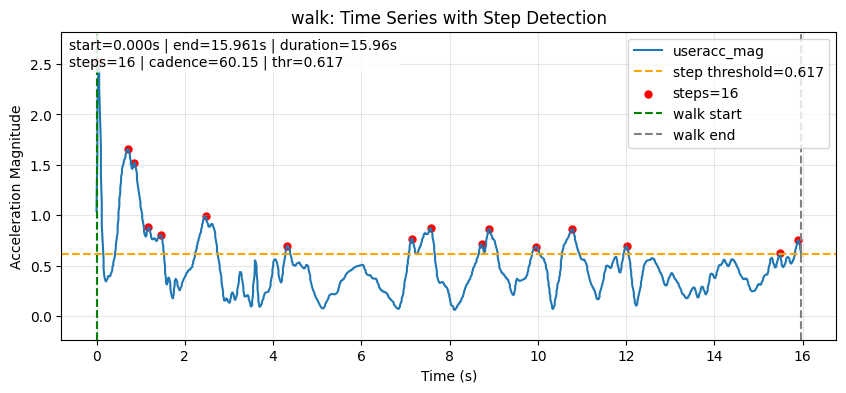

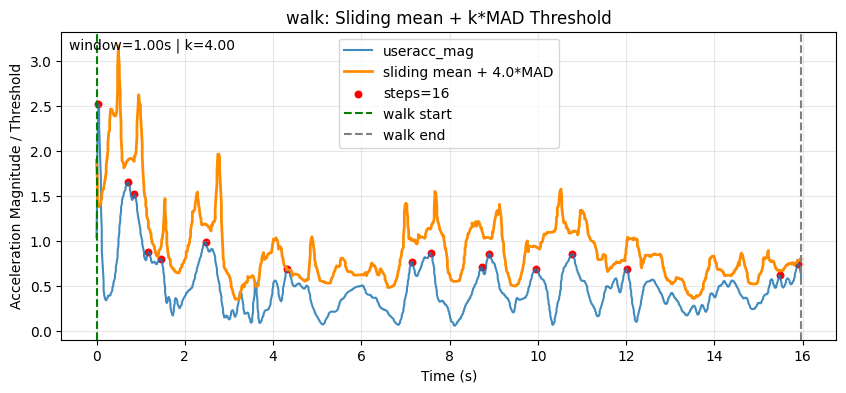

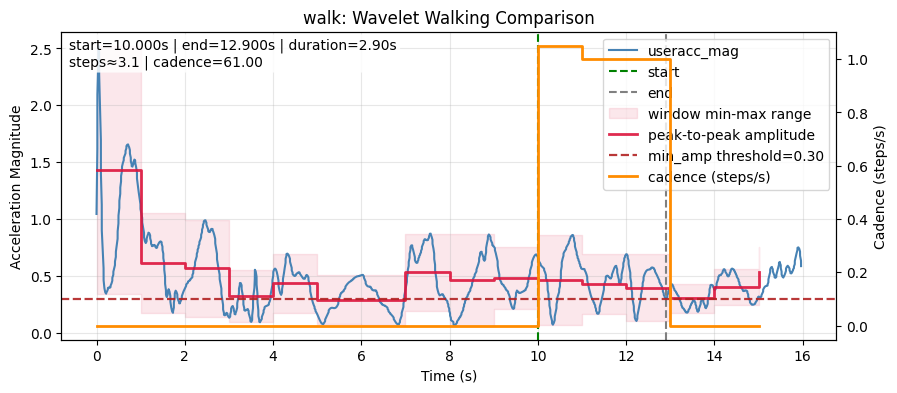

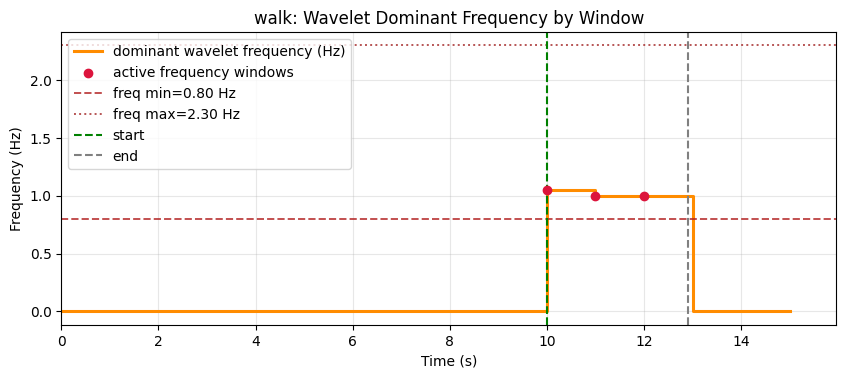

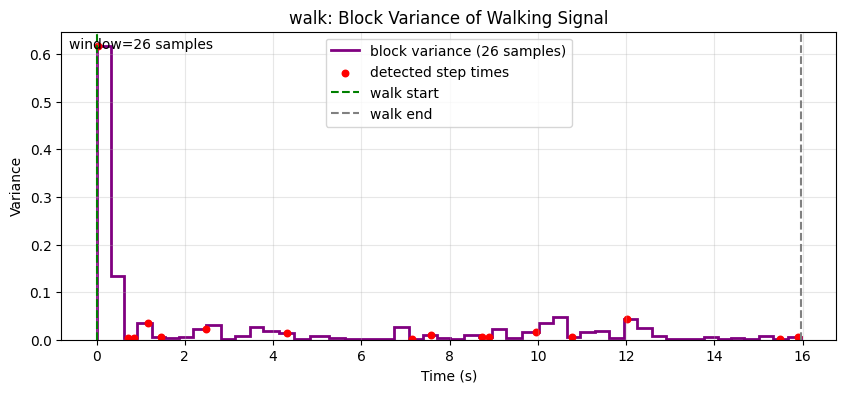

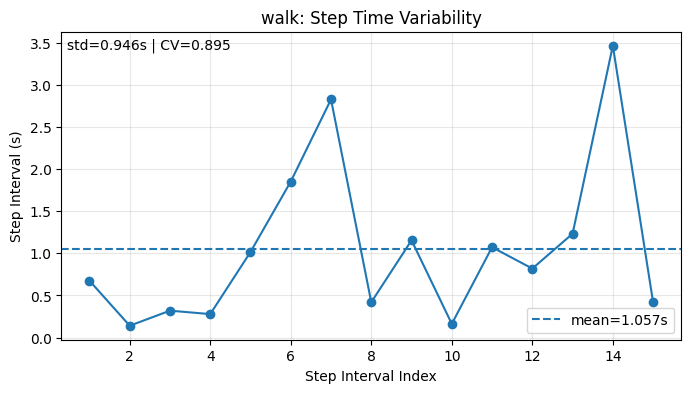

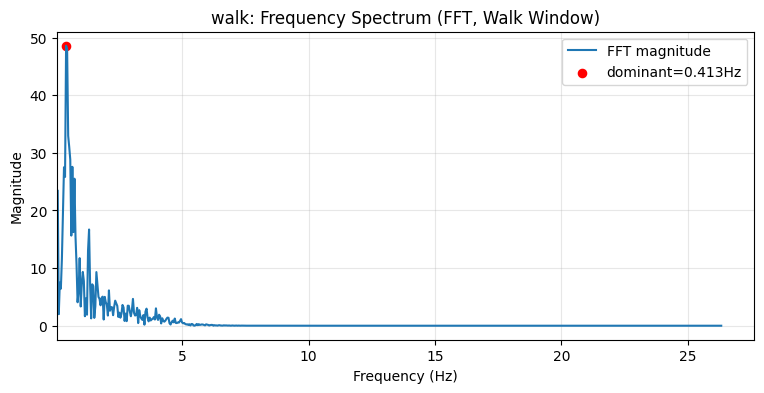

{'activity': 'walk', 'start_time_s': 0.0, 'end_time_s': 15.960999965667725, 'duration_s': 15.960999965667725, 'step_count': 16, 'cadence': 60.14660748480483}

[PROCESS] left_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/360_LeftTurn/synchronized/360° Left Turn-2025-03-23_12-36-15_synchronized.csv


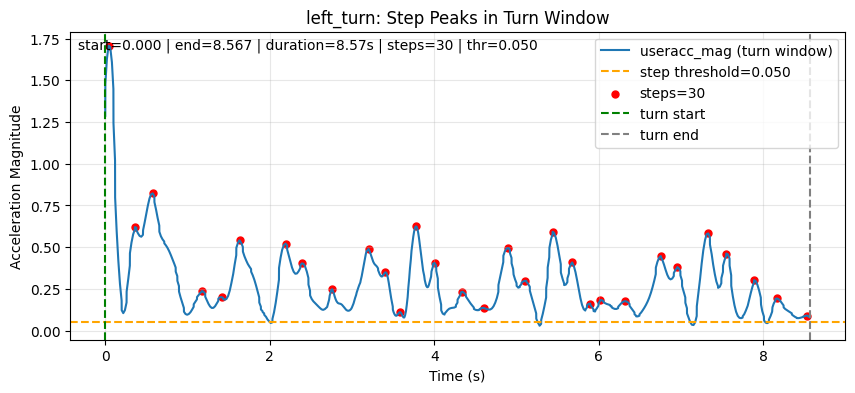

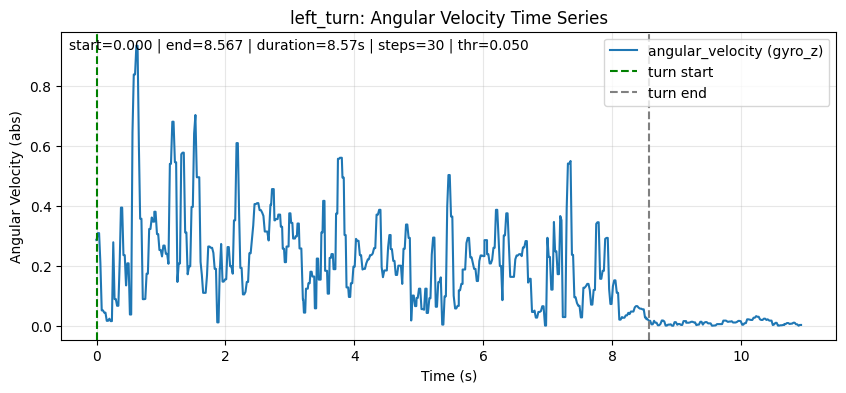

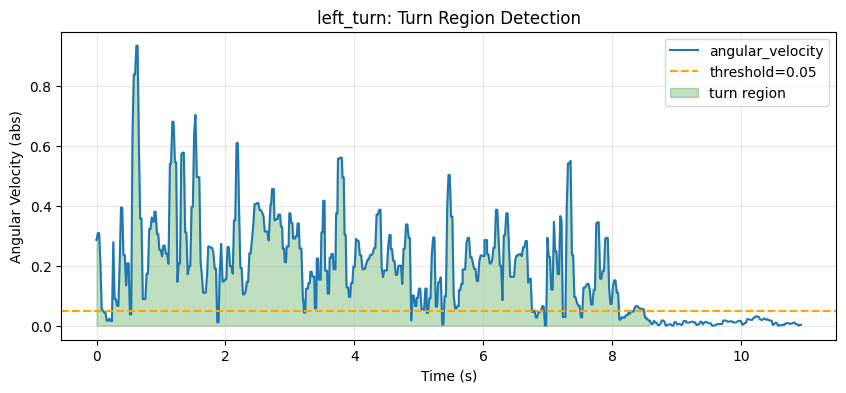

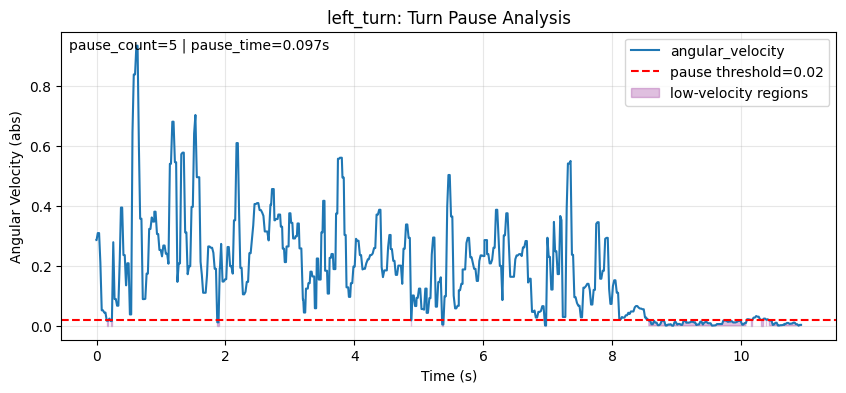

{'activity': 'left_turn', 'start_time_s': 0.0, 'end_time_s': 8.566999912261963, 'duration_s': 8.566999912261963, 'step_count': 30}

[PROCESS] right_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/360_RightTurn/synchronized/360° Right Turn-2025-03-23_12-37-01_synchronized.csv


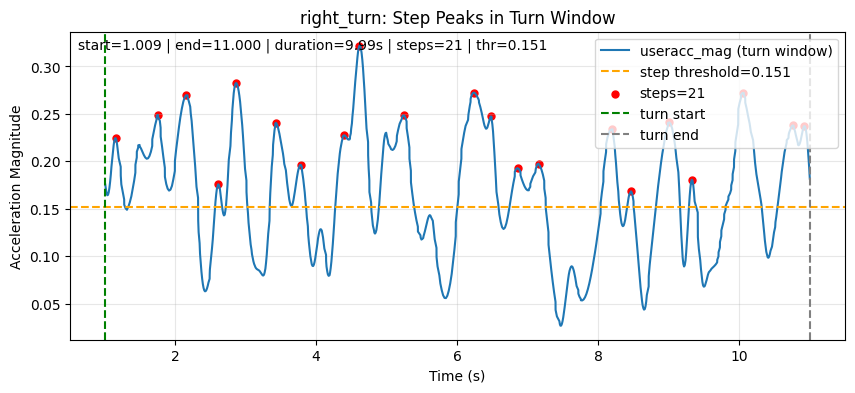

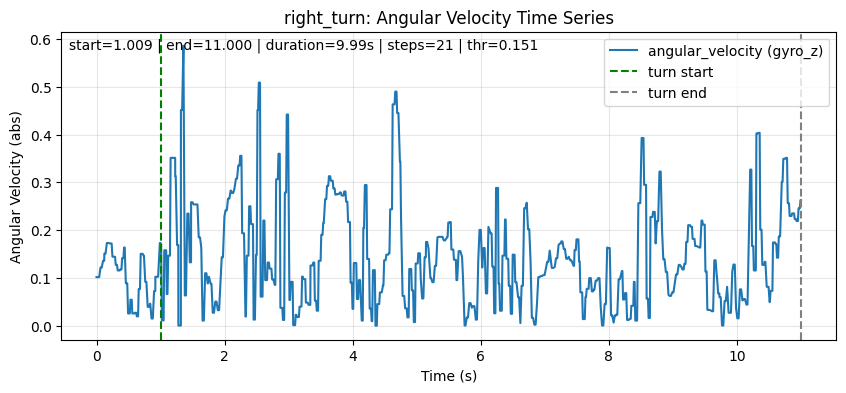

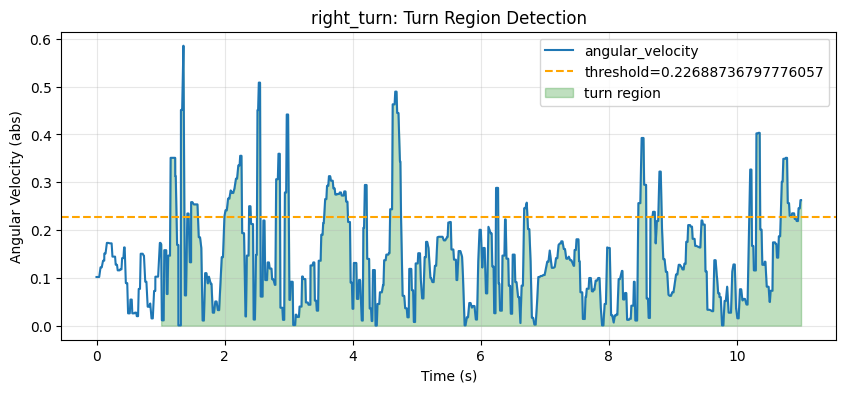

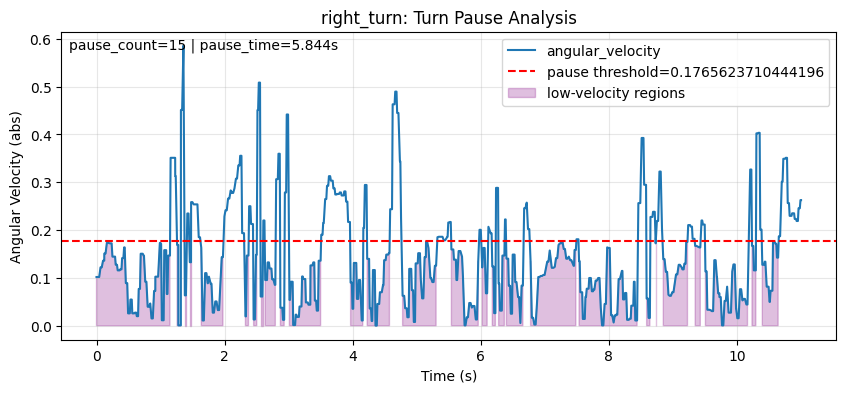

{'activity': 'right_turn', 'start_time_s': 1.0090000629425049, 'end_time_s': 11.0, 'duration_s': 9.990999937057495, 'step_count': 21}

[PROCESS] sit_to_stand: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/Sit_To_Stand/synchronized/exercise_data_2113_SRS007_synchronized.csv


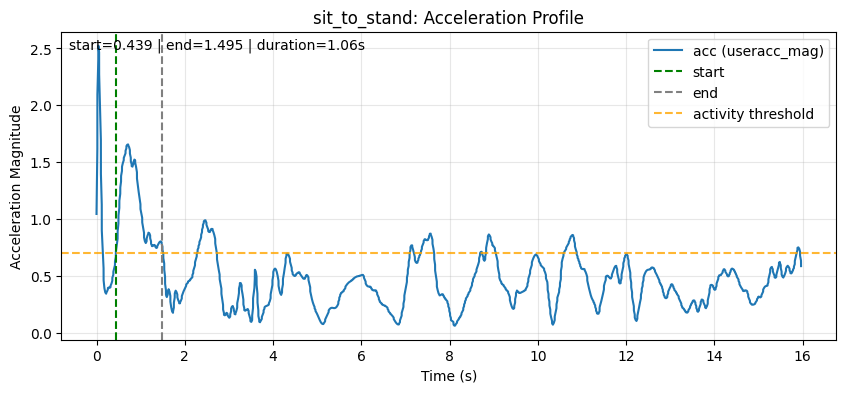

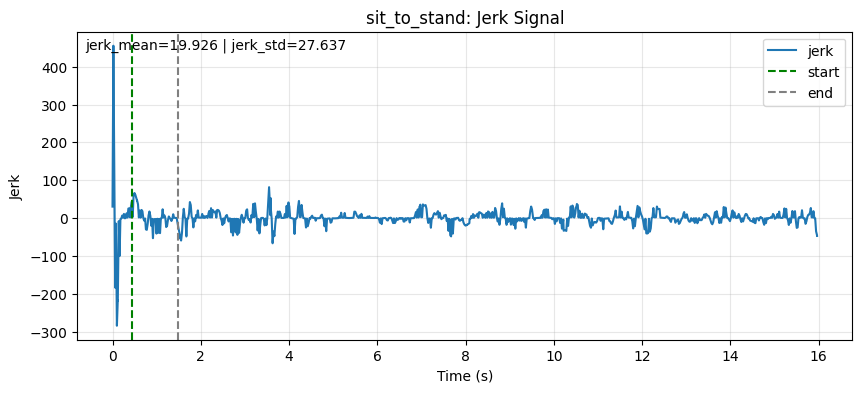

{'activity': 'sit_to_stand', 'start_time_s': 0.43899989128112793, 'end_time_s': 1.494999885559082, 'duration_s': 1.055999994277954}

[PROCESS] stand_to_sit: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/SRS07/D1_2025-03-23/Stand_To_Sit/synchronized/exercise_data_2115_SRS007_synchronized.csv


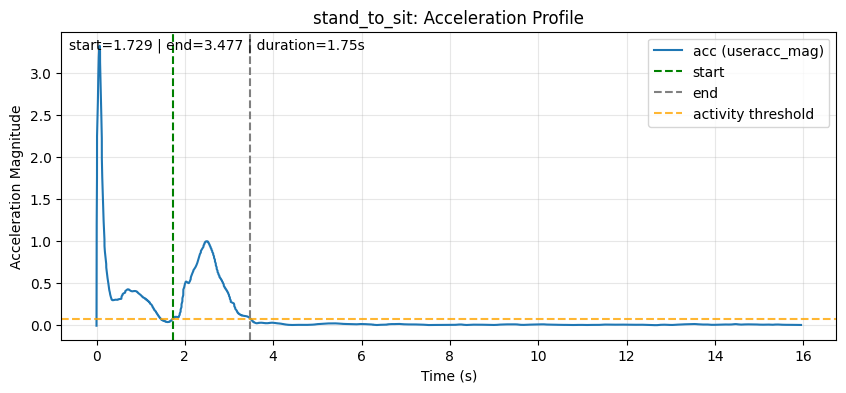

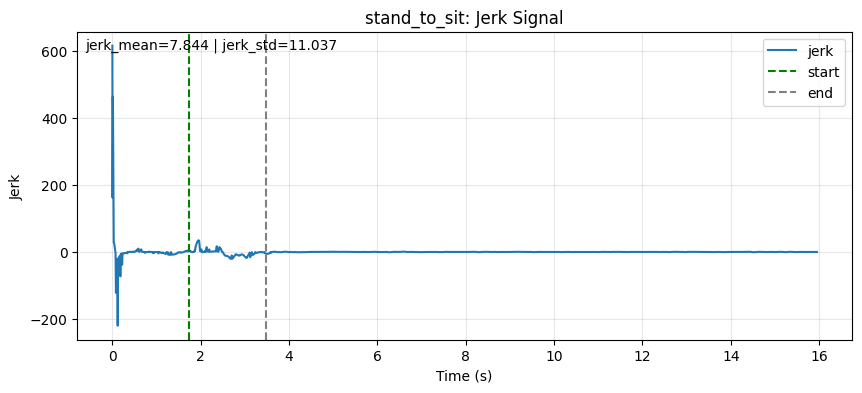

{'activity': 'stand_to_sit', 'start_time_s': 1.7290000915527344, 'end_time_s': 3.4769999980926514, 'duration_s': 1.747999906539917}


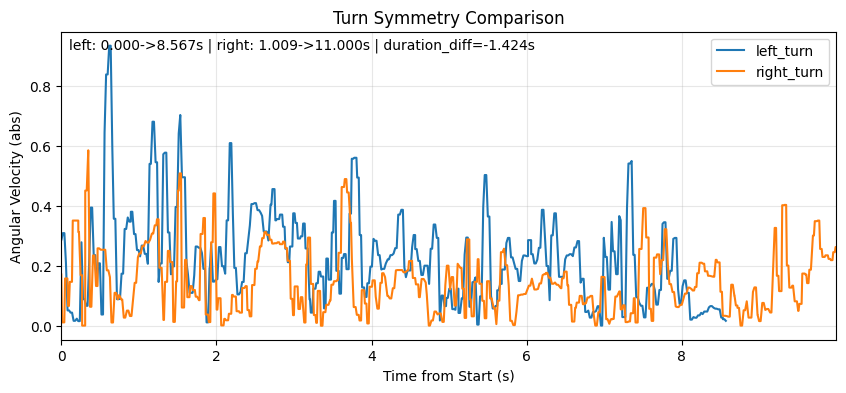

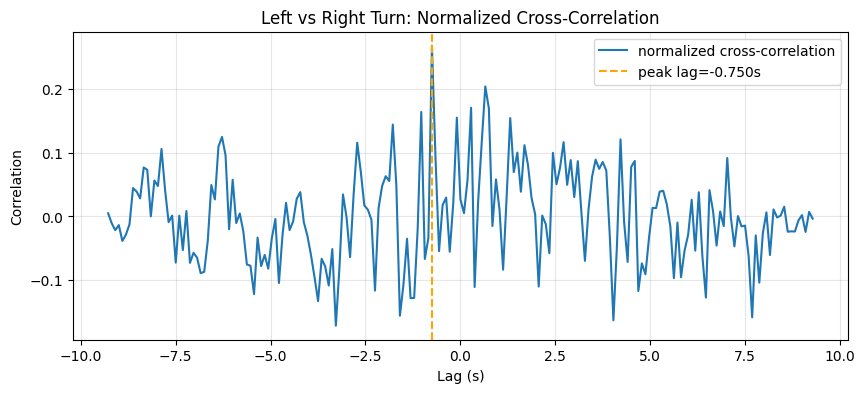

{'activity': 'turn_left_right_xcorr', 'xcorr_peak': 0.2673781737701653, 'xcorr_peak_lag_s': -0.7498181757300791}


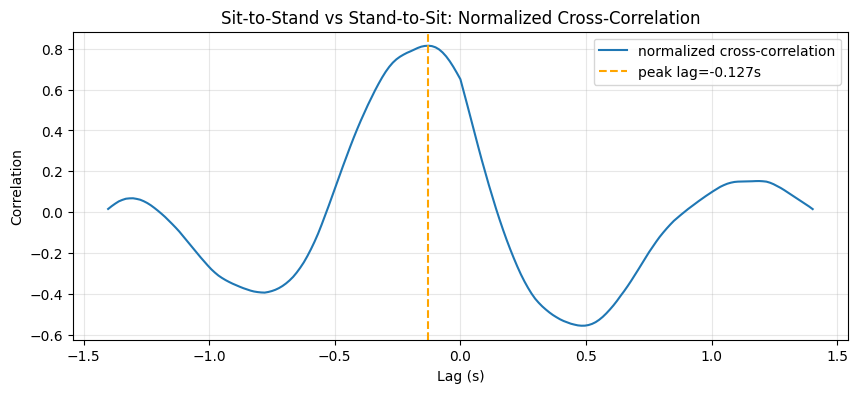

{'activity': 'sitstand_standsit_xcorr', 'xcorr_peak': 0.815188781247743, 'xcorr_peak_lag_s': -0.12745454094626688}

=== Validation Summary ===


,activity,start_time_s,end_time_s,duration_s,step_count,cadence,xcorr_peak,xcorr_peak_lag_s
0,walk,0.000,15.961,15.961,16.0,60.146607,NaN,NaN
1,left_turn,0.000,8.567,8.567,30.0,NaN,NaN,NaN
2,right_turn,1.009,11.000,9.991,21.0,NaN,NaN,NaN
3,sit_to_stand,0.439,1.495,1.056,NaN,NaN,NaN,NaN
4,stand_to_sit,1.729,3.477,1.748,NaN,NaN,NaN,NaN
5,turn_left_right_xcorr,NaN,NaN,NaN,NaN,NaN,0.267378,-0.749818
6,sitstand_standsit_xcorr,NaN,NaN,NaN,NaN,NaN,0.815189,-0.127455


In [7]:
if CHOSEN_DIR is not None:
    BASE_DIR = Path(CHOSEN_DIR)
else:
    BASE_DIR = resolve_date_dir(DATA_ROOT, PATIENT_ID, DATE)
    if DATE is None:
        DATE = BASE_DIR.name

selected_activities = SELECTED_ACTIVITIES if SELECTED_ACTIVITIES is not None else ACTIVITY_FILTER
activity_files = discover_activity_files(BASE_DIR, selected_activities)

print("Base directory:", BASE_DIR)
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")

all_summaries = []
turn_cache = {}
transition_cache = {}

for activity in ["walk", "left_turn", "right_turn", "sit_to_stand", "stand_to_sit"]:
    if activity not in activity_files:
        print(f"[SKIP] {activity}: not available")
        continue

    path = activity_files[activity]
    print(f"\n[PROCESS] {activity}: {path}")
    try:
        df, meta = load_activity_file(path)
    except Exception as e:
        print(f"[WARN] could not load {activity}: {e}")
        continue

    if activity == "walk":
        summary = plot_walk_validation(activity, df, meta)
        all_summaries.append(summary)
        print(summary)
    elif activity in {"left_turn", "right_turn"}:
        summary, cache = plot_turn_validation(activity, df, meta)
        all_summaries.append(summary)
        turn_cache[activity] = cache
        print(summary)
    else:
        summary, cache = plot_transition_validation(activity, df, meta)
        all_summaries.append(summary)
        transition_cache[activity] = cache
        print(summary)

if "left_turn" in turn_cache and "right_turn" in turn_cache:
    plot_turn_symmetry_comparison(turn_cache["left_turn"], turn_cache["right_turn"])

    turn_corr = plot_turn_pair_xcorr(turn_cache["left_turn"], turn_cache["right_turn"])
    all_summaries.append(turn_corr)
    print(turn_corr)

if "sit_to_stand" in transition_cache and "stand_to_sit" in transition_cache:
    trans_corr = plot_transition_pair_xcorr(
        transition_cache["sit_to_stand"],
        transition_cache["stand_to_sit"],
    )
    all_summaries.append(trans_corr)
    print(trans_corr)

print("\n=== Validation Summary ===")
display(pd.DataFrame(all_summaries))
